# CFP_Scoring_Rules

Violation rate comparison and Diebold-Mariano pairwise test heatmap.

**Output:** `fig_violation_rates.pdf`, `fig_dm_heatmap.pdf`  
**Paper:** Pele, Bolovaneanu, Ginavar, Lessmann, Härdle (2026)  
**Q** [Conformal_Oracle](https://github.com/QuantLet/Conformal_Oracle/)

Loaded 864 rows


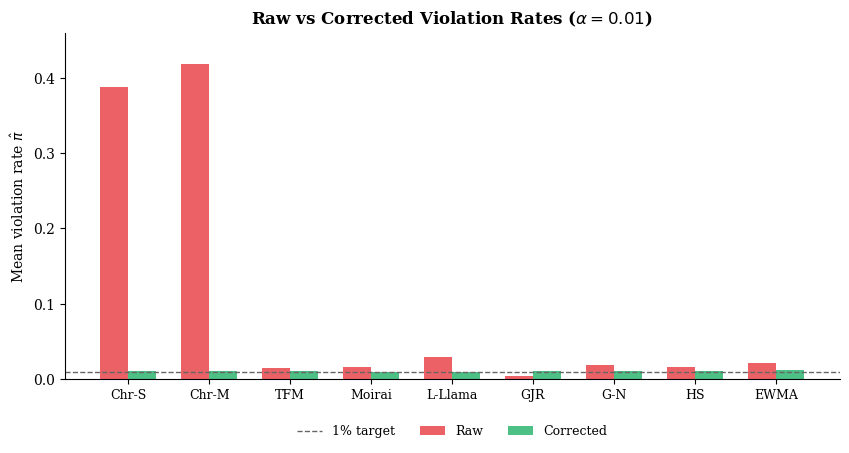

Saved fig_violation_rates


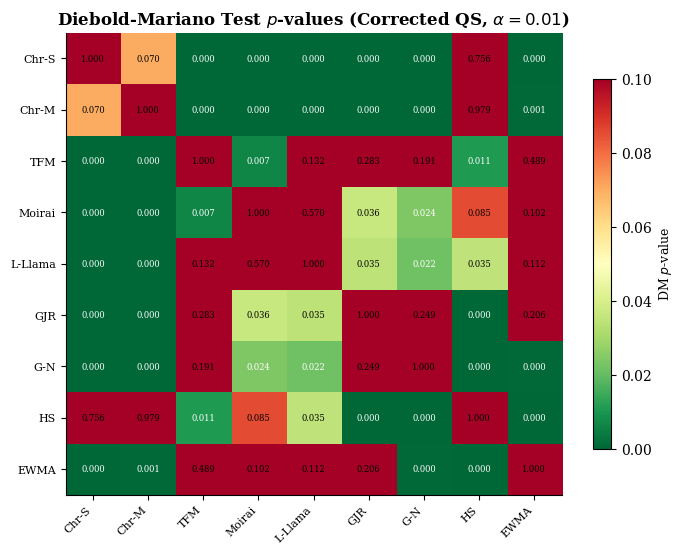

Saved fig_dm_heatmap


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import shutil, warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────
DATA_DIR = Path('../../cfp_ijf_data')
RES_DIR  = DATA_DIR / 'paper_outputs' / 'tables'
FIG_DIR  = DATA_DIR / 'paper_outputs' / 'figures'
ROOT_FIG = Path('../../figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
ROOT_FIG.mkdir(parents=True, exist_ok=True)

# ── Style ─────────────────────────────────────────────
C_GRAY='#666666'; C_TEAL='#00A651'; C_RED='#E31E24'
C_BLUE='#0066CC'; C_PURPLE='#7B2FBE'
plt.rcParams.update({
    'font.family':'serif', 'axes.grid':False,
    'savefig.transparent':True, 'savefig.dpi':300,
    'axes.spines.top':False, 'axes.spines.right':False,
    'font.size':10,
})

# ── Data ───────────────────────────────────────────────────────────
df  = pd.read_csv(RES_DIR / 'all_results.csv')
d01 = df[df['alpha'] == 0.01].copy()
print(f'Loaded {len(df)} rows')

MODEL_ORDER = ['Chronos-Small','Chronos-Mini','TimesFM-2.5',
               'Moirai-2.0','Lag-Llama',
               'GJR-GARCH','GARCH-N','Hist-Sim','EWMA']
MODEL_SHORT = ['Chr-S','Chr-M','TFM','Moirai','L-Llama',
               'GJR','G-N','HS','EWMA']

# ═══════════════════════════════════════════════════════════════════
# FIG: Violation Rates (raw vs corrected)
# ═══════════════════════════════════════════════════════════════════
summary = d01.groupby('model').agg(
    pi_raw=('pihat_raw','mean'),
    pi_cp=('pihat_cp','mean'),
).reindex(MODEL_ORDER)

x = np.arange(len(MODEL_ORDER))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - w/2, summary['pi_raw'], w, color=C_RED, alpha=0.7, label='Raw')
ax.bar(x + w/2, summary['pi_cp'], w, color=C_TEAL, alpha=0.7, label='Corrected')
ax.axhline(0.01, color=C_GRAY, ls='--', lw=1, label='1% target')
ax.set_title('Raw vs Corrected Violation Rates ($\\alpha = 0.01$)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(MODEL_SHORT, fontsize=9)
ax.set_ylabel(r'Mean violation rate $\hat{\pi}$')
ax.set_ylim(0, min(summary['pi_raw'].max()*1.1, 0.5))
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
          ncol=3, fontsize=9, frameon=False)
for ext in ['pdf','png']:
    fig.savefig(FIG_DIR / f'fig_violation_rates.{ext}', bbox_inches='tight')
for _ext in ['pdf','png']:
    shutil.copy(FIG_DIR/f'fig_violation_rates.{_ext}', ROOT_FIG/f'fig_violation_rates.{_ext}')
plt.show()
print('Saved fig_violation_rates')

# ═══════════════════════════════════════════════════════════════════
# FIG: DM Heatmap
# ═══════════════════════════════════════════════════════════════════
dm_path = RES_DIR / 'dm_pvalues_matrix.csv'
if dm_path.exists():
    dm = pd.read_csv(dm_path, index_col=0)
    models_dm = [m for m in MODEL_ORDER if m in dm.index and m in dm.columns]
    mat = dm.loc[models_dm, models_dm].values.astype(float)
    short_dm = [MODEL_SHORT[MODEL_ORDER.index(m)] for m in models_dm]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(mat, cmap='RdYlGn_r', vmin=0, vmax=0.10, aspect='auto')
    ax.set_title('Diebold-Mariano Test $p$-values (Corrected QS, $\\alpha = 0.01$)',
                 fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(short_dm)))
    ax.set_xticklabels(short_dm, fontsize=8, rotation=45, ha='right')
    ax.set_yticks(range(len(short_dm)))
    ax.set_yticklabels(short_dm, fontsize=8)
    for i in range(len(models_dm)):
        for j in range(len(models_dm)):
            v = mat[i,j]
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    fontsize=6, color='white' if v < 0.025 else 'black')
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('DM $p$-value', fontsize=9)
    for ext in ['pdf','png']:
        fig.savefig(FIG_DIR / f'fig_dm_heatmap.{ext}', bbox_inches='tight')
    for _ext in ['pdf','png']:
        shutil.copy(FIG_DIR/f'fig_dm_heatmap.{_ext}', ROOT_FIG/f'fig_dm_heatmap.{_ext}')
    plt.show()
    print('Saved fig_dm_heatmap')
else:
    print('dm_pvalues_matrix.csv not found — skipped')